In [30]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.style.use("default")

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [48]:
data = load_digits()
X = data.data / 16.0
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=128,
    shuffle=True
)

Device: cuda


Training: 100%|██████████| 600/600 [00:07<00:00, 75.00it/s, epoch=49, loss=675.939]


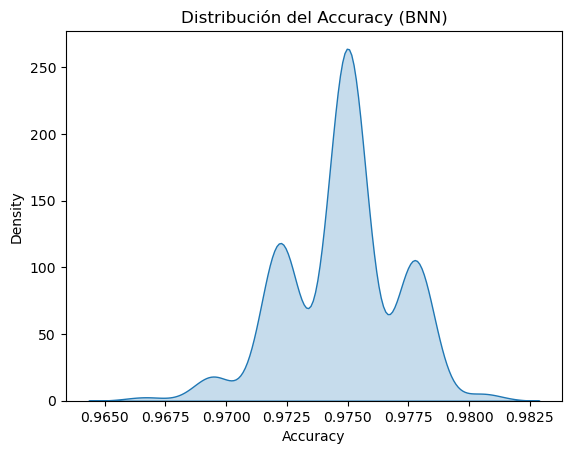

Mean: 0.97475004
Std: 0.002242776
Percentiles: [0.97222227 0.97500002 0.97777778]


In [98]:
# =========================
# 2. Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# =========================
# 3. Dataset
# =========================
data = load_digits()
X = data.data / 16.0
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

N = X_train.shape[0]

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=128,
    shuffle=True
)


# =========================
# 4. Bayesian Linear (vectorizada)
# =========================
class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.prior_sigma = prior_sigma

        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_rho = nn.Parameter(torch.empty(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_rho = nn.Parameter(torch.empty(out_features))

        self.reset_parameters()

    def reset_parameters(self):

        nn.init.kaiming_normal_(self.weight_mu)
        self.weight_rho.data.fill_(-5)
        nn.init.zeros_(self.bias_mu)
        self.bias_rho.data.fill_(-5)

    def forward(self, x, n_samples=1):


        sigma_w = torch.log1p(torch.exp(self.weight_rho))
        sigma_b = torch.log1p(torch.exp(self.bias_rho))

        if x.dim() == 2:
            x = x.unsqueeze(0).expand(n_samples, *x.shape)

        S = x.size(0)

        eps_w = torch.randn(S, *self.weight_mu.shape, device=x.device)
        eps_b = torch.randn(S, *self.bias_mu.shape, device=x.device)

        weight = self.weight_mu + sigma_w * eps_w
        bias = self.bias_mu + sigma_b * eps_b

        out = torch.einsum("sbi,soi->sbo", x, weight) + bias.unsqueeze(1)

        return out

    def kl(self, mu, rho):

        sigma = torch.log1p(torch.exp(rho))

        return (
                torch.log(self.prior_sigma / sigma)
                + (sigma**2 + mu**2) / (2 * self.prior_sigma**2)
                - 0.5
            ).sum()

    def kl_loss(self):

        return self.kl(self.weight_mu, self.weight_rho) + self.kl(self.bias_mu, self.bias_rho)


# =========================
# 5. Red Bayesiana
# =========================
class BayesianNN(nn.Module):
    def __init__(self, prior_sigma=1.0):

        super().__init__()
        self.fc1 = BayesianLinear(64, 128, prior_sigma)
        self.fc2 = BayesianLinear(128, 64, prior_sigma)
        self.fc3 = BayesianLinear(64, 10, prior_sigma)

    def forward(self, x, n_samples=1):

        x = torch.relu(self.fc1(x, n_samples))
        x = torch.relu(self.fc2(x, n_samples))
        x = self.fc3(x, n_samples)

        return x

    def kl_loss(self):
        return self.fc1.kl_loss() + self.fc2.kl_loss() + self.fc3.kl_loss()


# =========================
# 6. ELBO (multi-sample)
# =========================
def elbo_loss(model, x, y, n_samples=1, beta=1e-2):
    logits = model(x, n_samples=n_samples)  # (S, B, C)

    S, B, C = logits.shape

    y_expand = y.unsqueeze(0).expand(S, B)

    logits_flat = logits.reshape(S * B, C)
    y_flat = y_expand.reshape(S * B)

    nll = F.cross_entropy(logits_flat, y_flat, reduction='mean')

    kl = model.kl_loss()

    loss = nll*(N/B) + beta * kl

    return loss


# =========================
# 7. Entrenamiento
# =========================
model = BayesianNN(prior_sigma=1.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs =50

progress_bar = tqdm(total=num_epochs * len(train_loader), desc="Training")

for epoch in range(num_epochs):
    model.train()

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        loss = elbo_loss(model, x_batch, y_batch, n_samples=10)

        loss.backward()
        optimizer.step()

        # actualizar barra
        progress_bar.update(1)
        progress_bar.set_postfix({
            "epoch": epoch,
            "loss": f"{loss.item():.3f}"
        })

progress_bar.close()


# =========================
# 8. Muestras de accuracy (vectorizado)
# =========================
def sample_accuracies(model, X_test, y_test, n_samples=200):
    model.eval()

    X_test = X_test.to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        logits = model(X_test, n_samples=n_samples)  # (S, N, C)
        preds = logits.argmax(dim=2)

        correct = (preds == y_test.unsqueeze(0))
        accs = correct.float().mean(dim=1)

    return accs.cpu().numpy()


acc_samples = sample_accuracies(model, X_test, y_test, 200)


# =========================
# 9. Densidad del accuracy
# =========================
sns.kdeplot(acc_samples, fill=True)
plt.xlabel("Accuracy")
plt.title("Distribución del Accuracy (BNN)")
plt.show()


# =========================
# 10. Estadísticas
# =========================
print("Mean:", np.mean(acc_samples))
print("Std:", np.std(acc_samples))
print("Percentiles:", np.percentile(acc_samples, [5, 50, 95]))

In [99]:
class BayesianConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, prior_sigma=1.0):
        super().__init__()

        self.stride = stride
        self.padding = padding
        self.prior_sigma = prior_sigma

        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)

        # parámetros variacionales
        self.weight_mu = nn.Parameter(
            torch.empty(out_channels, in_channels, *kernel_size)
        )
        self.weight_rho = nn.Parameter(
            torch.empty(out_channels, in_channels, *kernel_size)
        )

        self.bias_mu = nn.Parameter(torch.empty(out_channels))
        self.bias_rho = nn.Parameter(torch.empty(out_channels))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_normal_(self.weight_mu)
        self.weight_rho.data.fill_(-5)

        nn.init.zeros_(self.bias_mu)
        self.bias_rho.data.fill_(-5)

    def forward(self, x, n_samples=1):
        # x: (B, C, H, W)

        sigma_w = torch.log1p(torch.exp(self.weight_rho))
        sigma_b = torch.log1p(torch.exp(self.bias_rho))

        outputs = []

        for _ in range(n_samples):
            eps_w = torch.randn_like(self.weight_mu)
            eps_b = torch.randn_like(self.bias_mu)

            weight = self.weight_mu + sigma_w * eps_w
            bias = self.bias_mu + sigma_b * eps_b

            out = F.conv2d(
                x,
                weight,
                bias,
                stride=self.stride,
                padding=self.padding
            )

            outputs.append(out)

        return torch.stack(outputs)  # (S, B, C, H, W)

    def kl_loss(self):
        def kl(mu, rho):
            sigma = torch.log1p(torch.exp(rho))
            return (
                torch.log(self.prior_sigma / sigma)
                + (sigma**2 + mu**2) / (2 * self.prior_sigma**2)
                - 0.5
            ).sum()

        return kl(self.weight_mu, self.weight_rho) + kl(self.bias_mu, self.bias_rho)

In [100]:
class BayesianCNN(nn.Module):
    def __init__(self, prior_sigma=1.0):
        super().__init__()

        self.conv1 = BayesianConv2d(1, 16, 3, padding=1, prior_sigma=prior_sigma)
        self.conv2 = BayesianConv2d(16, 32, 3, padding=1, prior_sigma=prior_sigma)

        self.fc1 = BayesianLinear(32 * 2 * 2, 64, prior_sigma)
        self.fc2 = BayesianLinear(64, 10, prior_sigma)

        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x, n_samples=1):
        B = x.size(0)
        x = x.view(B, 1, 8, 8)

        # -------- Conv1 --------
        x = self.conv1(x, n_samples)      # (S, B, 16, 8, 8)
        x = torch.relu(x)

        S, B, C, H, W = x.shape
        x = x.view(S * B, C, H, W)
        x = self.pool(x)
        x = x.view(S, B, C, H//2, W//2)   # (S, B, 16, 4, 4)

        # -------- Conv2 --------
        x = x.view(S * B, 16, 4, 4)
        x = self.conv2(x, n_samples=1)    # (1, S*B, 32, 4, 4)
        x = torch.relu(x)

        # quitar dimensión extra de samples
        x = x.squeeze(0)                  # (S*B, 32, 4, 4)

        x = self.pool(x)                  # (S*B, 32, 2, 2)

        # -------- Flatten --------
        x = x.view(S, B, -1)              # (S, B, 32*2*2)

        # -------- FC --------
        x = torch.relu(self.fc1(x, n_samples))
        x = self.fc2(x, n_samples)

        return x

    def kl_loss(self):
        return (
            self.conv1.kl_loss() +
            self.conv2.kl_loss() +
            self.fc1.kl_loss() +
            self.fc2.kl_loss()
        )

In [101]:
model = BayesianCNN(prior_sigma=1.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
total_steps = num_epochs * len(train_loader)

with tqdm(total=total_steps, desc="Training", leave=True) as pbar:

    for epoch in range(num_epochs):
        model.train()

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            loss = elbo_loss(model, x_batch, y_batch, n_samples=1)

            loss.backward()
            optimizer.step()

            # actualizar barra
            pbar.update(1)
            pbar.set_postfix(loss=f"{loss.item():.3f}", epoch=epoch)


Training: 100%|██████████| 600/600 [00:09<00:00, 62.72it/s, epoch=49, loss=548.884]


In [102]:
def sample_accuracies(model, X_test, y_test, n_samples=200):
    model.eval()

    X_test = X_test.to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        logits = model(X_test, n_samples=n_samples)  # (S, N, C)
        preds = logits.argmax(dim=2)                # (S, N)

        correct = (preds == y_test.unsqueeze(0))    # (S, N)
        accs = correct.float().mean(dim=1)          # (S,)

    return accs.cpu().numpy()
acc_samples = sample_accuracies(model, X_test, y_test, n_samples=200)

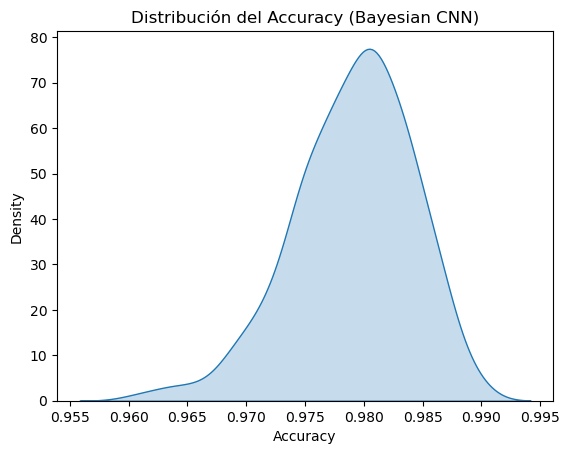

In [103]:
import matplotlib.pyplot as plt
sns.kdeplot(acc_samples, fill=True)
plt.xlabel("Accuracy")
plt.title("Distribución del Accuracy (Bayesian CNN)")
plt.show()

In [104]:
np.quantile(acc_samples, [0.05, 0.95])

array([0.96944445, 0.98611116])

In [22]:


w_mu = model.conv1.weight_mu
w_sigma = torch.log1p(torch.exp(model.conv1.weight_rho))

print("Mean:", w_mu.mean().item())
print("Std of sigma:", w_sigma.mean().item())

Mean: 0.10878981649875641
Std of sigma: 0.006697637028992176


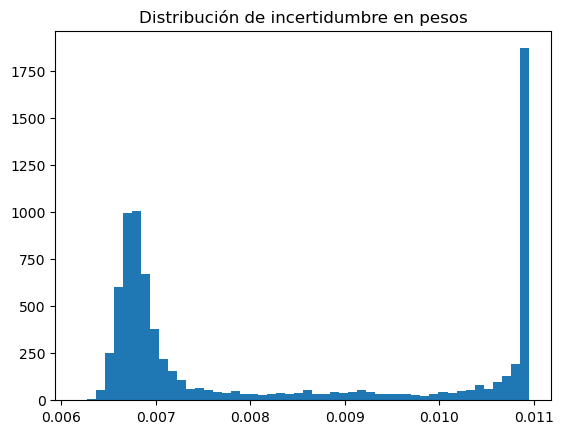

In [24]:
sigma = torch.log1p(torch.exp(model.fc1.)).detach().cpu().numpy()

plt.hist(sigma.flatten(), bins=50)
plt.title("Distribución de incertidumbre en pesos")
plt.show()

In [30]:
def sample_weights(layer):
    sigma_w = torch.log1p(torch.exp(layer.weight_rho))
    eps = torch.randn_like(layer.weight_mu)
    return layer.weight_mu + sigma_w * eps

In [31]:
w_sample = sample_weights(model.conv1)
print(w_sample)

tensor([[[[ 0.5624,  0.4189,  0.2472],
          [ 0.4864,  0.5612, -0.1857],
          [-0.1324, -0.2590, -0.0150]]],


        [[[ 0.0123,  0.0499,  0.4734],
          [ 0.1491, -0.8471,  0.0945],
          [-0.2208, -0.3037,  1.1969]]],


        [[[ 0.1060, -0.1866, -0.0105],
          [ 0.0899, -0.6355, -0.7558],
          [ 0.0199,  1.1035,  0.1710]]],


        [[[ 0.2503, -0.4379,  0.4100],
          [ 0.0440,  0.6876,  0.0372],
          [-0.5749,  0.5098,  0.9777]]],


        [[[ 0.3471,  0.3319,  0.2856],
          [-0.3668, -0.3514, -0.0142],
          [ 0.1208, -0.0121, -0.2403]]],


        [[[ 0.0528,  0.5872,  0.0590],
          [ 1.1377,  0.7462, -0.2128],
          [-0.0058, -0.0848,  0.5435]]],


        [[[ 0.3953,  0.0416, -0.4067],
          [ 0.6624,  0.2737, -0.1881],
          [-0.0458,  0.5235, -0.9800]]],


        [[[ 0.5919,  0.7497, -0.4598],
          [-0.7615,  0.4513, -0.2551],
          [-0.3725,  0.4456,  0.3158]]],


        [[[-0.2497, -0.3400,  0.

In [33]:
model.fc2.weight_mu

Parameter containing:
tensor([[-9.7648e-02, -3.1972e-01, -1.5887e-01, -4.8683e-02, -7.6924e-02,
         -7.6538e-02,  8.8928e-03, -3.7893e-01, -2.5987e-06, -7.0764e-03,
          4.4585e-02, -5.1149e-02, -1.6249e-01, -8.1142e-02,  2.3918e-01,
         -9.0461e-03, -1.2478e-01, -3.4993e-01, -1.6045e-01,  1.1655e-01,
          1.9463e-01, -5.3355e-03,  1.3156e-02, -1.1571e-01,  2.6125e-02,
         -1.1572e-01,  3.3883e-01, -5.3767e-02, -1.7839e-01, -2.4150e-03,
          2.3182e-05,  1.1308e-02,  3.1380e-01, -1.3562e-01, -1.1269e-01,
          2.3827e-01, -1.0605e-02, -5.8838e-01, -1.6790e-01, -1.4130e-01,
         -1.5215e-01, -7.9551e-02, -4.1527e-02,  4.4963e-01,  9.7325e-03,
         -2.8583e-01,  1.9597e-01,  7.9419e-02,  1.2589e-04, -1.8505e-01,
          1.9261e-01,  1.1559e-01, -1.3592e-01,  1.3689e-01, -3.7981e-09,
          2.1159e-01, -1.5877e-01,  2.8401e-01,  4.8801e-02, -1.8798e-01,
         -2.0084e-01,  1.0032e-01, -1.5550e-02,  3.7518e-02],
        [ 2.9257e-01, -1.880

In [29]:
for name, param in model.named_parameters():
    print(name, param)

conv1.weight_mu Parameter containing:
tensor([[[[ 5.5782e-01,  4.2274e-01,  2.4738e-01],
          [ 4.8491e-01,  5.6583e-01, -1.8868e-01],
          [-1.4807e-01, -2.7295e-01, -2.2814e-02]]],


        [[[ 1.5940e-02,  4.4825e-02,  4.7660e-01],
          [ 1.4548e-01, -8.5123e-01,  9.1320e-02],
          [-2.2182e-01, -3.0233e-01,  1.1967e+00]]],


        [[[ 1.1999e-01, -1.8241e-01,  1.2789e-03],
          [ 8.6599e-02, -6.5141e-01, -7.4861e-01],
          [ 1.6508e-02,  1.0989e+00,  1.6054e-01]]],


        [[[ 2.6630e-01, -4.3987e-01,  4.1370e-01],
          [ 3.5819e-02,  6.9410e-01,  2.6334e-02],
          [-5.8342e-01,  4.9147e-01,  9.8177e-01]]],


        [[[ 3.4595e-01,  3.2908e-01,  2.8112e-01],
          [-3.7689e-01, -3.5760e-01, -1.5639e-02],
          [ 1.2209e-01, -2.3403e-02, -2.4118e-01]]],


        [[[ 5.3003e-02,  5.8812e-01,  5.4413e-02],
          [ 1.1331e+00,  7.3702e-01, -2.1118e-01],
          [ 6.2380e-03, -8.6799e-02,  5.5209e-01]]],


        [[[ 3.9206e-

In [28]:
for p in model.parameters():
    if p.requires_grad:
         print(p.name, p.data)

None tensor([[[[ 5.5782e-01,  4.2274e-01,  2.4738e-01],
          [ 4.8491e-01,  5.6583e-01, -1.8868e-01],
          [-1.4807e-01, -2.7295e-01, -2.2814e-02]]],


        [[[ 1.5940e-02,  4.4825e-02,  4.7660e-01],
          [ 1.4548e-01, -8.5123e-01,  9.1320e-02],
          [-2.2182e-01, -3.0233e-01,  1.1967e+00]]],


        [[[ 1.1999e-01, -1.8241e-01,  1.2789e-03],
          [ 8.6599e-02, -6.5141e-01, -7.4861e-01],
          [ 1.6508e-02,  1.0989e+00,  1.6054e-01]]],


        [[[ 2.6630e-01, -4.3987e-01,  4.1370e-01],
          [ 3.5819e-02,  6.9410e-01,  2.6334e-02],
          [-5.8342e-01,  4.9147e-01,  9.8177e-01]]],


        [[[ 3.4595e-01,  3.2908e-01,  2.8112e-01],
          [-3.7689e-01, -3.5760e-01, -1.5639e-02],
          [ 1.2209e-01, -2.3403e-02, -2.4118e-01]]],


        [[[ 5.3003e-02,  5.8812e-01,  5.4413e-02],
          [ 1.1331e+00,  7.3702e-01, -2.1118e-01],
          [ 6.2380e-03, -8.6799e-02,  5.5209e-01]]],


        [[[ 3.9206e-01,  3.3645e-02, -4.0712e-01],
  